In [72]:
import os
import sys
from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns
import infinite
reload(plotting)
reload(pinns)
reload(infinite)
import numpy as np
import sympy as sp
import pickle
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [73]:
model_u, model_k = build_models_KAN(
    device,
    hidden_layers=3,
    hidden_units=5,
    grid_size=3,
    spline_order=3,
)
 


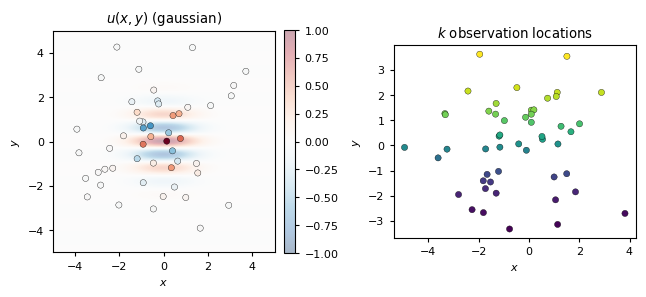

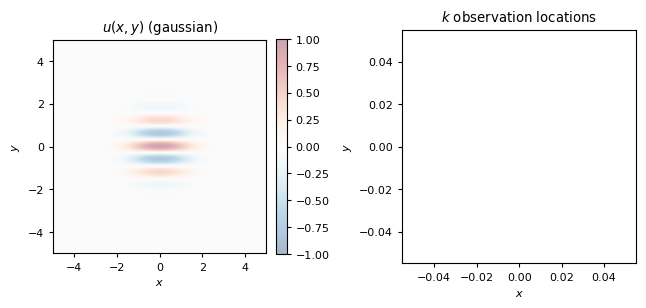

In [74]:
# Training data
(
    X_obs_train,
    U_obs_train,
    X_obs_k_train,
    K_obs_train,
    X_pde_train,
    F_pde_train,
    *_,
) = generate_dataset_inf(
    n_obs_u=50,
    n_obs_k=50,
    n_pde=500,
    plot=True,
    device=device,
    sampling="gaussian"
)

# Test data
(
    X_obs_test,
    U_obs_test,
    X_obs_k_test,
    K_obs_test,
    X_pde_test,
    F_pde_test,
    *_,
) = generate_dataset_inf(
    n_obs_u=0,
    n_obs_k=0,
    n_pde=0,
    plot=True,
    device=device,
    sampling="gaussian"
)

In [75]:
history = train_dual_network(
    model_u,
    model_k,
    X_obs_train,
    U_obs_train,
    X_obs_k_train,
    K_obs_train,
    X_pde_train,
    F_pde_train,
    X_obs_test,
    U_obs_test,
    X_obs_k_test,
    K_obs_test,
    X_pde_test,
    F_pde_test,
    adam_lr=1e-4,
    adam_iters=3000,
    lbfgs_iters=3000,
    adaptive_weights=False,
    verbose=True,
    regularization=False,
)


Training with Adam
Adam     0 | Total=1.892e+02 | ObsU=6.790e-02 | ObsK=4.534e+00 | PDE=1.846e+02 | Ratio=2718.65
Adam   100 | Total=1.891e+02 | ObsU=6.716e-02 | ObsK=4.466e+00 | PDE=1.846e+02 | Ratio=2736.20
Adam   200 | Total=1.890e+02 | ObsU=6.693e-02 | ObsK=4.378e+00 | PDE=1.846e+02 | Ratio=2754.22
Adam   300 | Total=1.889e+02 | ObsU=6.695e-02 | ObsK=4.258e+00 | PDE=1.846e+02 | Ratio=2758.69
Adam   400 | Total=1.887e+02 | ObsU=6.749e-02 | ObsK=4.093e+00 | PDE=1.846e+02 | Ratio=2748.93
Adam   500 | Total=1.884e+02 | ObsU=6.963e-02 | ObsK=3.866e+00 | PDE=1.845e+02 | Ratio=2700.08
Adam   600 | Total=1.877e+02 | ObsU=7.643e-02 | ObsK=3.539e+00 | PDE=1.841e+02 | Ratio=2546.17
Adam   700 | Total=1.857e+02 | ObsU=9.381e-02 | ObsK=3.042e+00 | PDE=1.826e+02 | Ratio=2185.13
Adam   800 | Total=1.797e+02 | ObsU=1.253e-01 | ObsK=2.314e+00 | PDE=1.773e+02 | Ratio=1668.15
Adam   900 | Total=1.647e+02 | ObsU=1.765e-01 | ObsK=1.435e+00 | PDE=1.631e+02 | Ratio=1154.81
Adam  1000 | Total=1.387e+02 |

Relative L2 error (u): 3.658e-01
Relative L2 error (k): 2.707e-01


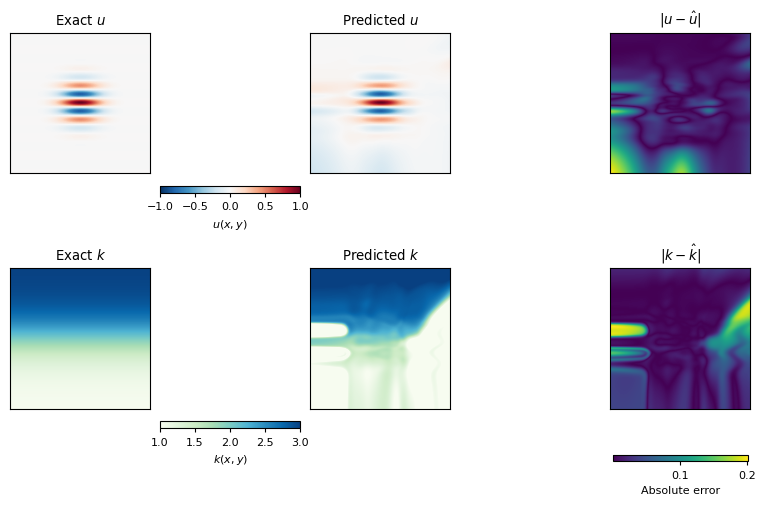

In [76]:
err_u, err_k = evaluate_model_inf(
    model_u,
    model_k,
    analytical_solution_inf,
    coefficient_inf,
    device=device,
    save_results=False,
    verbose=True,
    plot=True
)

In [77]:
import efficient_kan
 

In [78]:
from efficient_kan import KAN
print(KAN)
model = KAN(
    layers_hidden=[2, 5, 5, 5, 1],
    grid_size=3,
    spline_order=3,
)

<class 'efficient_kan.kan.KAN'>
